In [1]:
import sys
sys.path.append('/scratch/marian/IC')
ic_course_path = '/scratch/marian/ic-course'
# sys.path.append(f'{ic_course_path}')

import numpy  as np
import pandas as pd
import tables as tb
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
font_size = 20

# Configure matplotlib
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.size'] = font_size

# Line properties
plt.rcParams['lines.linewidth'] = 2.5  # Default line width
plt.rcParams['lines.markersize'] = 8   # Default marker size
plt.rcParams['lines.linestyle'] = '-'  # Default line style
plt.rcParams['lines.marker'] = None    # Default marker (None for no marker)
plt.rcParams['lines.markeredgewidth'] = 1.0  # Marker edge width

# Set default color cycle (replaces the default light colors)
# colors = ['blue', 'deepskyblue', 'lightcoral', 'darkseagreen', 'plum']  # Define a list of colors
# plt.rcParams['axes.prop_cycle'] = plt.cycler(color=colors)

/tmp/ipykernel_424259/434847695.py:12: MatplotlibDeprecationWarning: Support for setting an rcParam that expects a str value to a non-str value is deprecated since 3.5 and support will be removed two minor releases later.
  plt.rcParams['lines.marker'] = None    # Default marker (None for no marker)


In [3]:
V25v0 = np.array([51, 51.3, 51.5, 51.8, 51.9, 52.005, 52.245, 52.675, 53, 53.195, 53.395, 53.74, 54.035, 54.30, 54.865, 55.345, 55.755, 56, 56.25, 56.5])
I25v0 = np.array([.66e-3, .68e-3, .69e-3, .70e-3, .80e-3, 1e-3, 10e-3, 101e-3, .216, .301, .403, .606, .805, 1.00, 1.50, 2.00, 2.50, 2.83, 3.19, 3.58])

V22 = np.array([51, 51.3, 51.5, 51.8, 51.9, 51.94, 52.165, 52.645, 53, 53.22, 53.435, 53.815, 54.13, 54.42, 55.025, 55.525, 55.95, 56, 56.25, 56.5])
I22 = np.array([.50e-3, .50e-3, .60e-3, .70e-3, .80e-3, 1e-3, 10e-3, 100e-3, .214, .302, .401, .604, .800, 1.00, 1.50, 2.00, 2.50, 2.57, 2.89, 3.25])

V19 = np.array([51, 51.3, 51.5, 51.75, 51.84, 51.88, 52.105, 52.625, 53, 53.25, 53.485, 53.89, 54.23, 54.525, 55.17, 55.685, 56, 56.125, 56.25, 56.5])
I19 = np.array([.50e-3, .50e-3, .50e-3, .60e-3, .80e-3, 1e-3, 10e-3, 100e-3, .210, .302, .402, .604, .803, 1.00, 1.50, 2.00, 2.36, 2.50, 2.65, 2.98])

V16 = np.array([51, 51.3, 51.5, 51.72, 51.78, 51.815, 52.035, 52.61, 53, 53.29, 53.55, 53.985, 54.35, 54.665, 55.33, 55.87, 56, 56.10, 56.32, 56.5])
I16 = np.array([.47e-3, .47e-3, .58e-3, .60e-3, .80e-3, 1e-3, 10e-3, 100e-3, .204, .301, .402, .604, .803, 1.00, 1.50, 2.00, 2.14, 2.25, 2.50, 2.74])

V13 = np.array([51, 51.3, 51.5, 51.67, 51.72, 51.755, 51.975, 52.605, 53, 53.34, 53.61, 54.07, 54.46, 54.79, 55.485, 56, 56.04, 56.27, 56.49, 56.5])
I13 = np.array([.40e-3, .40e-3, .41e-3, .60e-3, .80e-3, 1e-3, 10e-3, 101e-3, .197, .302, .404, .604, .803, 1.00, 1.50, 1.97, 2.00, 2.25, 2.50, 2.52])

V10 = np.array([51, 51.3, 51.5, 51.65, 51.68, 51.705, 51.935, 52.60, 53, 53.365, 53.655, 54.13, 54.535, 54.89, 55.61, 56, 56.18, 56.38, 56.43, 56.5])
I10 = np.array([.36e-3, .36e-3, .41e-3, .60e-3, .80e-3, 1e-3, 10e-3, 100e-3, .192, .300, .402, .602, .803, 1.00, 1.50, 1.83, 2.00, 2.2, 2.25, 2.33])


In [4]:
V25v1 = np.array([40.0, 42.5, 45.0, 47.5, 50, 51.5, 51.8, 52.0, 52.1, 52.2, 52.3, 52.4, 52.5, 52.6, 52.7, 52.8, 52.9, 53.0, 54.0, 55.0, 55.5, 56.0, 56.2, 56.4, 56.5, 56.6, 56.7, 56.8, 56.9, 57.0, 58.0, 59.0, 60.0])
I25v1 = np.array([.6e-3, .6e-3, .6e-3, .6e-3, .6e-3, .65e-3, .7e-3, 1e-3, 2.4e-3, 7.5e-3, 18.5e-3, 35e-3, 55e-3, 79e-3, 107e-3, 127e-3, 173e-3, 0.21, 0.75, 1.59, 2.13, 2.77, 3.04, 3.35, 3.51, 3.67, 3.84, 4.01, 4.18, 4.37, 6.5, 9.4, 13.16])

# V22 = np.array([])
# I22 = np.array([])

# V19 = np.array([])
# I19 = np.array([])

# V16 = np.array([])
# I16 = np.array([])

# V13 = np.array([])
# I13 = np.array([])

# V10 = np.array([])
# I10 = np.array([])


In [5]:
# DIFFERENT SiPM
V25v2 = np.array([40.0, 42.5, 45.0, 47.5, 50, 51.5, 51.8, 52.0, 52.1, 52.2, 52.3, 52.4, 52.5, 52.6, 52.7, 52.8, 52.9, 53.0, 54.0, 55.0, 55.5, 56.0, 56.2, 56.4, 56.5, 56.6, 56.7, 56.8, 56.9, 57.0, 58.0, 59.0, 60.0])
I25v2 = np.array([.55e-3, .55e-3, .6e-3, .6e-3, .6e-3, .7e-3, .9e-3, 4.8e-3, 13e-3, 27.5e-3, 46.2e-3, 69.5e-3, 95.7e-3, 125e-3, 160e-3, 196e-3, 0.23, 0.28, 0.87, 1.76, 2.33, 3.02, 3.31, 3.63, 3.79, 3.95, 4.14, 4.32, 4.5, 4.7, 6.92, 9.88, 13.72])

# Calculate the derivative dI/dV
dIdVv2 = np.gradient((I25v2), V25v2)

In [6]:
Vdict = {25:V25v1, 22:V22, 19:V19, 16:V16, 13:V13, 10:V10}
Idict = {25:I25v1, 22:I22, 19:I19, 16:I16, 13:I13, 10:I10}

dIdVdict = {}
for temp in Vdict.keys():
    dIdVdict[temp] = np.gradient(Idict[temp], Vdict[temp])

In [7]:
def recta(x, x0, m):
    return m*x + x0

In [8]:
def rectafit(x, y, y_errors, x0guess, mguess):

    initial_guess_x0    = x0guess
    initial_guess_m     = mguess

    initial_guess = [initial_guess_x0, initial_guess_m]

    # Perform the fit with bounds to keep parameters positive
    bounds = (0, 2e5)  # All parameters must be > 0

    # Perform the fit
    params, covariance = curve_fit(recta, x, y, p0=initial_guess, sigma=y_errors, absolute_sigma=True, maxfev=100000)

    for j in range(10):
        # Fit the model to the data
        lower = np.minimum(params * 0.8, params * 1.2)
        upper = np.maximum(params * 0.8, params * 1.2)
        bounds = (lower, upper)
        if any(bounds[0] - bounds[1] > 0):
            print(j)
            print(params*0.8 - params*1.2)
        params, covariance = curve_fit(recta, x, y, p0=params, sigma=y_errors, absolute_sigma=True, bounds = bounds, maxfev=100000)
        
    return params, covariance

In [9]:
# np.sqrt((x0err/m)**2 + (x0*merr/m**2)**2)

In [10]:
# print(x0, x0err)
# print(m, merr)
# print(-x0/m, np.sqrt((x0err/m)**2 + (x0*merr/m**2)**2))

In [11]:
# x0/m

In [12]:
# yy

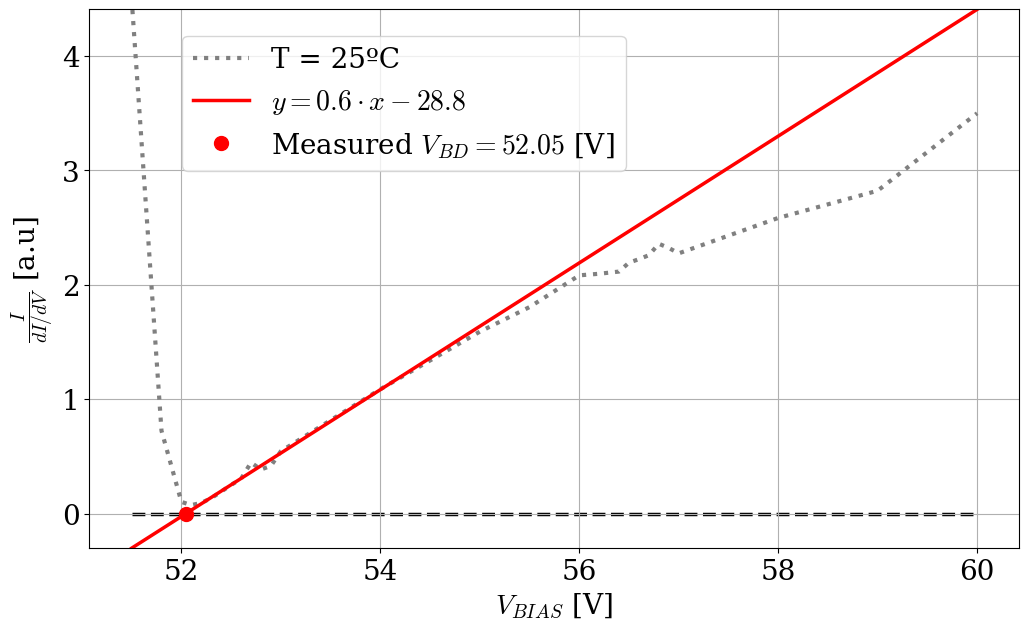

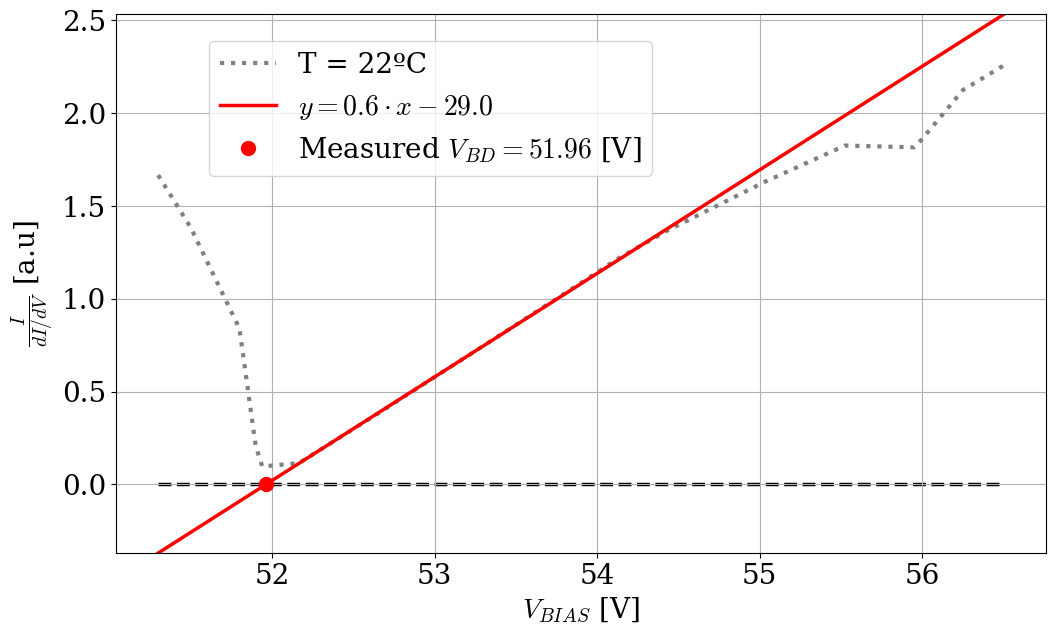

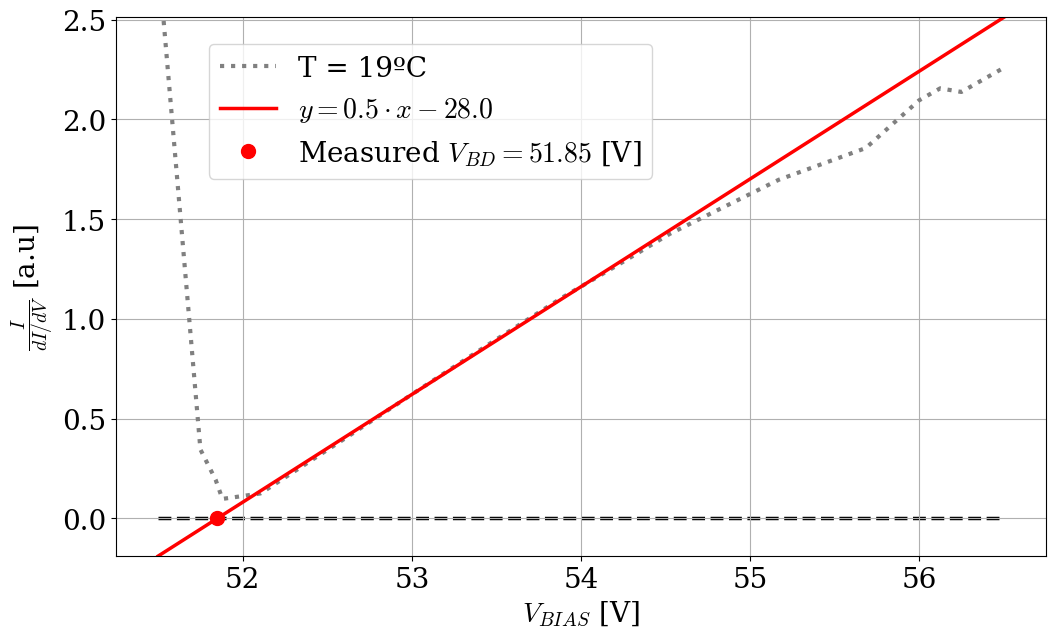

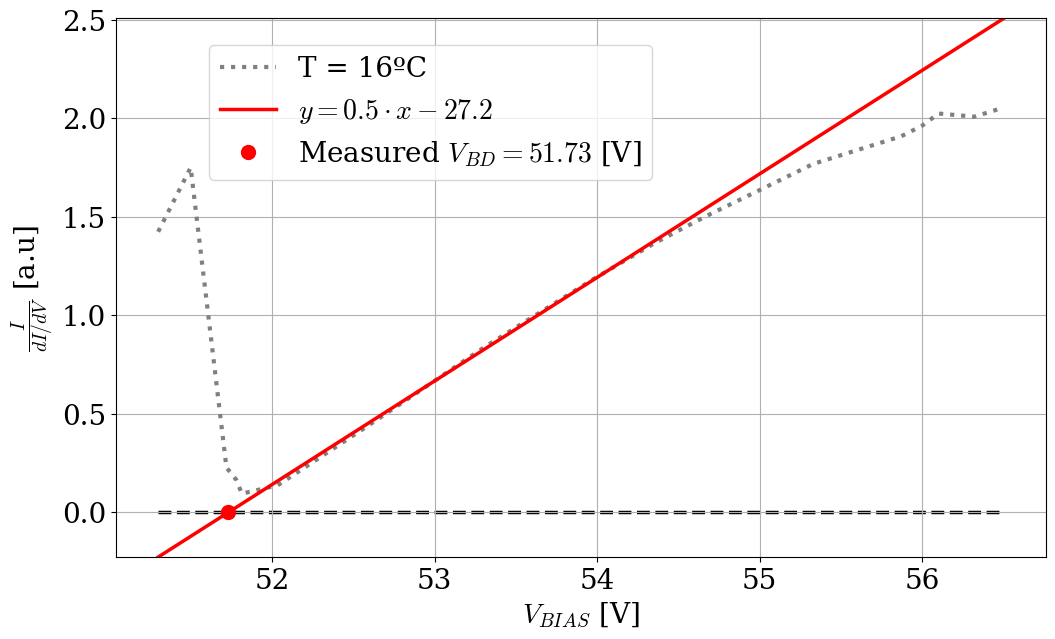

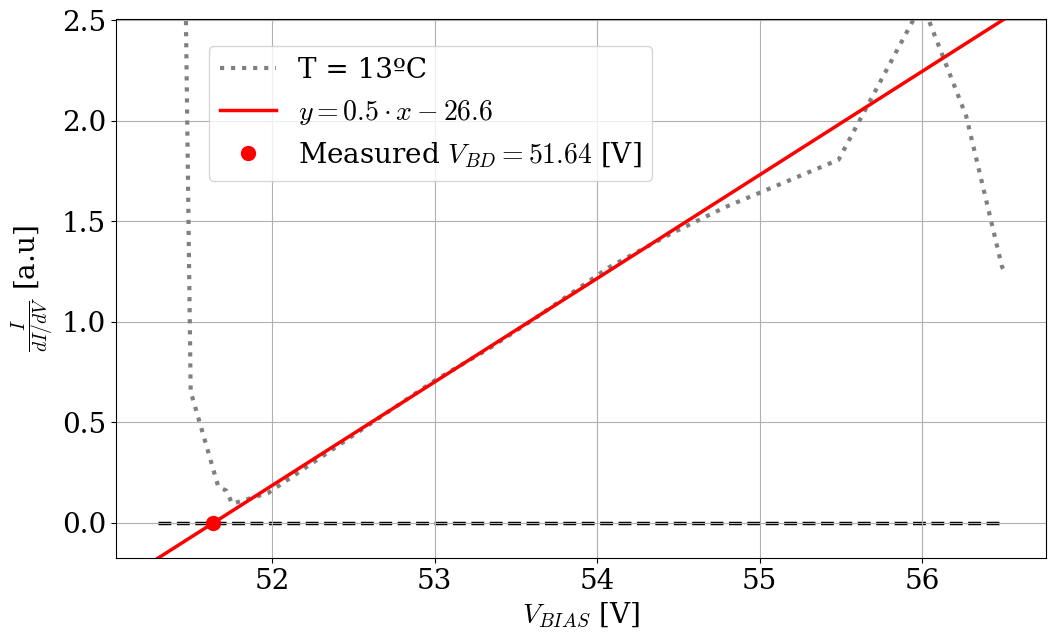

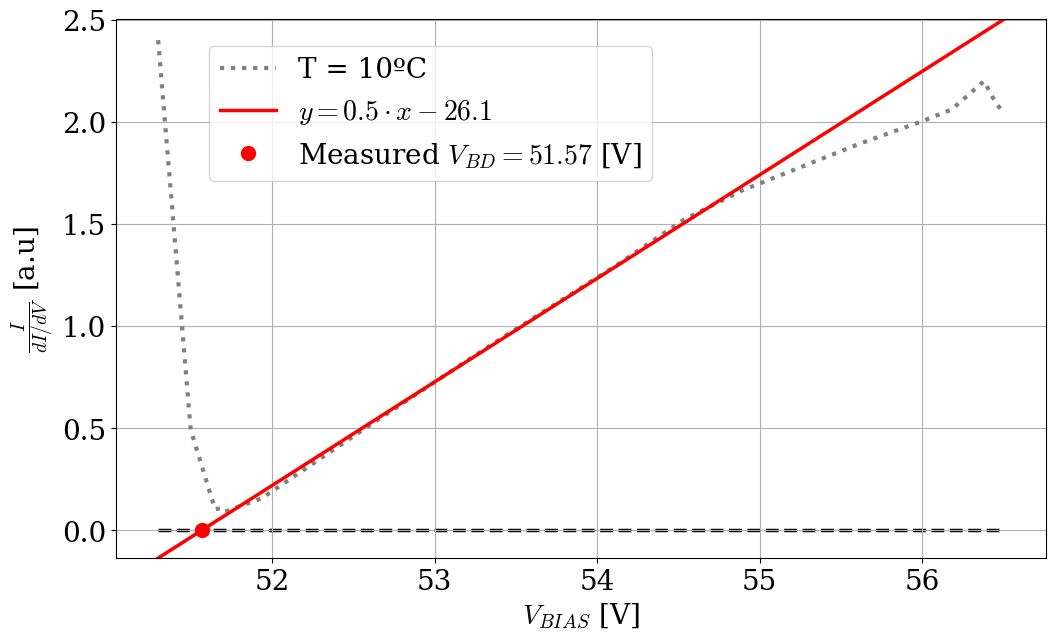

In [13]:
VBRdict = {}
VBRerrdict = {}

# Linear-fit region per temperature [V]. Edit these to change what's fitted.
# temp_low = 51.9
# temp_high = 55.6
temp_low = 52.2
temp_high = 54.5
fit_windows = {
    25: (temp_low, temp_high),
    22: (temp_low, temp_high),
    19: (temp_low, temp_high),
    16: (temp_low, temp_high),
    13: (temp_low, temp_high),
    10: (temp_low, 55.),
}

for temp in Vdict.keys():
    plt.figure(figsize=(12, 7))

    V = Vdict[temp]
    I = Idict[temp]
    dIdV = dIdVdict[temp]

    mask = dIdV > 0
    x = V[mask]
    y = I[mask]/dIdV[mask]

    y = y[x > 50]
    x = x[x > 50]

    plt.plot(x, y, ':', lw=3, color='grey', label=f'T = {temp}ºC')

    vlo, vhi = fit_windows[temp]
    xx = x[(x > vlo) & (x < vhi)]
    yy = y[(x > vlo) & (x < vhi)]

    # # shade the region actually used for the linear fit
    # plt.axvspan(vlo, vhi, color='orange', alpha=0.15, label=f'fit region [{vlo}, {vhi}] V')

    x0guess, mguess = -0.2, 0.6
    # plt.plot(xx, recta(xx, x0guess, mguess), label = 'recta guess')

    params, cov = rectafit(xx, yy, 1e-3*np.ones_like(yy), x0guess, mguess)
    x0, m = params
    # Compute the errors (standard deviations) for each parameter
    x0err, merr = np.sqrt(np.diag(cov))

    VBRdict[temp] = -x0/m
    VBRerrdict[temp] = np.sqrt((x0err/m)**2 + (x0*merr/m**2)**2)

    plt.plot(x, recta(x, *params), color='red', label = fr'$y = {m:.1f} \cdot x {x0:.1f}$')

    # plt.plot(53*np.ones_like(y), np.linspace(recta(x, *params).min(), recta(x, *params).max(), len(y)), ls=':', lw=3, color='grey', label=r'Reference $V_{BR}$')
    # plt.plot((-x0/m)*np.ones_like(y), np.linspace(recta(x, *params).min(), recta(x, *params).max(), len(y)), ls=':', lw=3, color='red', label=rf'Measured $V_{{BR}} = {-x0/m:.2f}$')
    plt.plot((-x0/m), recta(-x0/m, *params), 'o', color='red', markersize = 10, lw=3, label=rf'Measured $V_{{BD}} = {-x0/m:.2f}$ [V]')
    plt.hlines(0, x.min(), x.max(), color = 'k', linestyles='--', zorder = 1)

    plt.ylim(recta(x, *params).min() - 1e-3, recta(x, *params).max() + 1e-3)

    plt.ylabel(r"$\frac{I}{dI/dV}$ [a.u]")
    plt.xlabel(r"$V_{BIAS}$ [V]")
    plt.legend(loc=(0.1, 0.7))
    plt.grid()
    plt.show()


In [14]:
# deltay

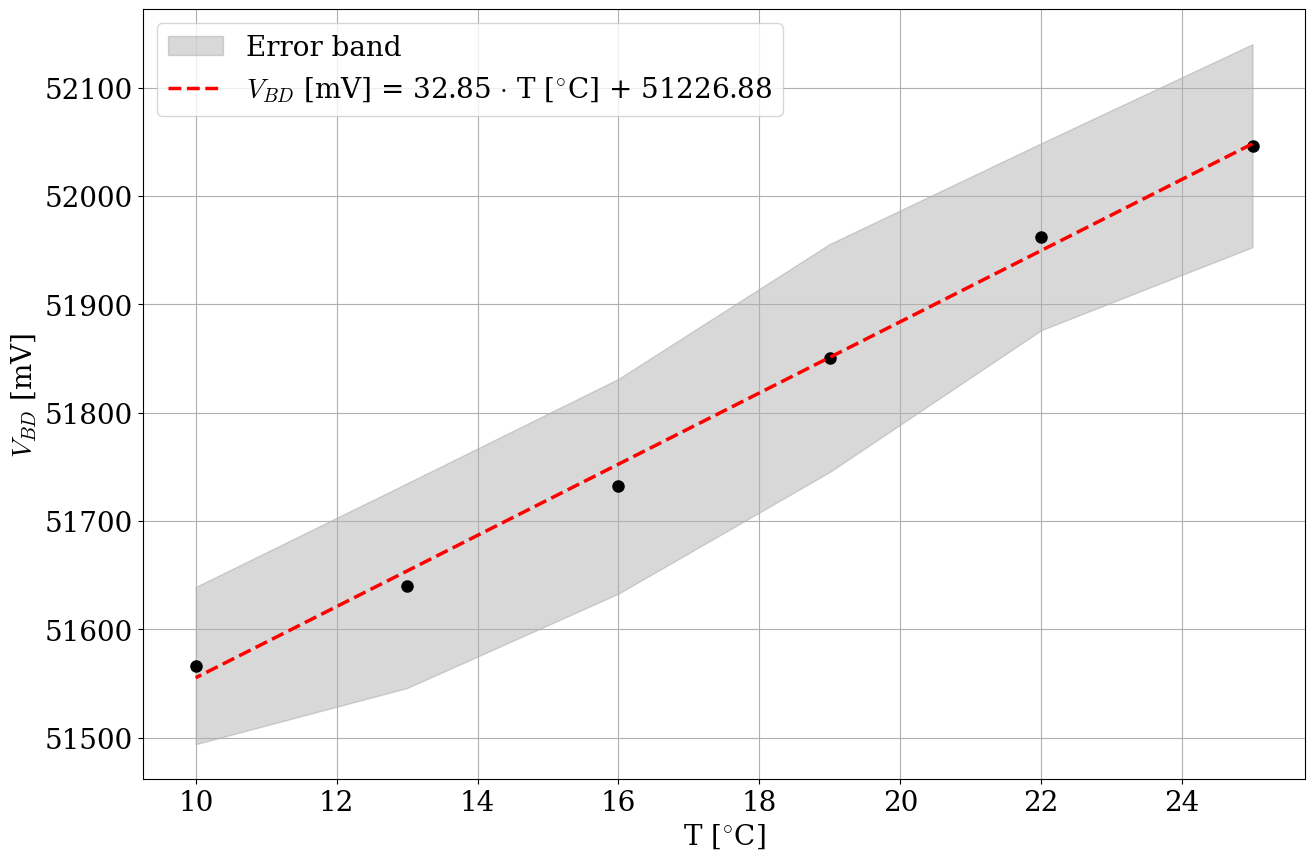

In [16]:
plt.figure(figsize=(15, 10))
x = np.array(list(VBRdict.keys()))
y = np.array(list(VBRdict.values()))*1e3
deltay = np.array(list(VBRerrdict.values()))*1e3

# plt.errorbar(x, y, yerr = deltay, fmt='-or', lw=3)
plt.plot(x, y, 'o', color='k', lw=3)
# Fill the error band
plt.fill_between(x, y - deltay, y + deltay, color='grey', alpha=0.3, label='Error band')

x0guess, mguess = 0.06, 50
# plt.plot(xx, recta(xx, x0guess, mguess), label = 'recta guess')

params, cov = rectafit(x, y, deltay, x0guess, mguess)
x0, m = params

plt.plot(x, recta(x, *params), '--r', label = fr'$V_{{BD}}$ [mV] = {m:.2f} $\cdot$ T [$^{{\circ}}$C] + {x0:.2f}')

plt.ylabel(r"$V_{BD}$ [mV]")
plt.xlabel(r"T [$^{\circ}$C]")
plt.legend(loc='upper left')
plt.grid()
plt.show()

In [42]:
28.85/0.554

52.07581227436823

In [17]:
def parabola (x, x0, A, B):
    return A*(x - x0)**2 + B


In [18]:
def parabfit(x, y, x0guess, Aguess, Bguess):

    initial_guess_x0    = x0guess
    initial_guess_A     = Aguess
    initial_guess_B     = Bguess

    initial_guess = [initial_guess_x0, initial_guess_A, initial_guess_B]

    # Perform the fit with bounds to keep parameters positive
    bounds = (0, 2e5)  # All parameters must be > 0

    # Perform the fit
    params, covariance = curve_fit(parabola, x, y, p0=initial_guess, maxfev=100000)

    for j in range(10):
        # Fit the model to the data
        lower = np.minimum(params * 0.8, params * 1.2)
        upper = np.maximum(params * 0.8, params * 1.2)
        bounds = (lower, upper)
        if any(bounds[0] - bounds[1] > 0):
            print(j)
            print(params*0.8 - params*1.2)
        params, covariance = curve_fit(parabola, x, y, p0=params, bounds = bounds, maxfev=100000)
        
    return params, covariance

In [19]:
params, cov = parabfit(x, y, x0guess, Aguess, Bguess)

NameError: name 'Aguess' is not defined

In [20]:
plt.figure(figsize=(15, 10))
x = V25
y = np.log(I25v2*1e3)
# plt.plot(V25, np.log(I25*1e3), lw=3, label=f'T = {25}ºC')
plt.plot(x, y, lw=3, label=f'T = {25}ºC first round')

xx = x[x > 51.5]
yy = y[x > 51.5]

x0guess, Aguess, Bguess = 56, -0.02, 7.5
plt.plot(xx, parabola(xx, x0guess, Aguess, Bguess), label = 'parabola guess')

params, cov = parabfit(xx, yy, x0guess, Aguess, Bguess)
plt.plot(xx, parabola(xx, *params), label = 'parabola fit')


plt.plot(53*np.ones_like(I25v2), np.linspace(np.log(I25v2*1e3).min(), np.log(I25v2*1e3).max(), len(I25)), ls=':', lw=3, label=r'Reference $V_{BR}$')

# plt.xlim(50., 55)
# plt.ylim(0, .4)

plt.ylabel(r"log(I) [$n$A]")
plt.xlabel(r"V [V]")
plt.legend()
plt.grid()

NameError: name 'V25' is not defined

<Figure size 1500x1000 with 0 Axes>

NameError: name 'I25' is not defined

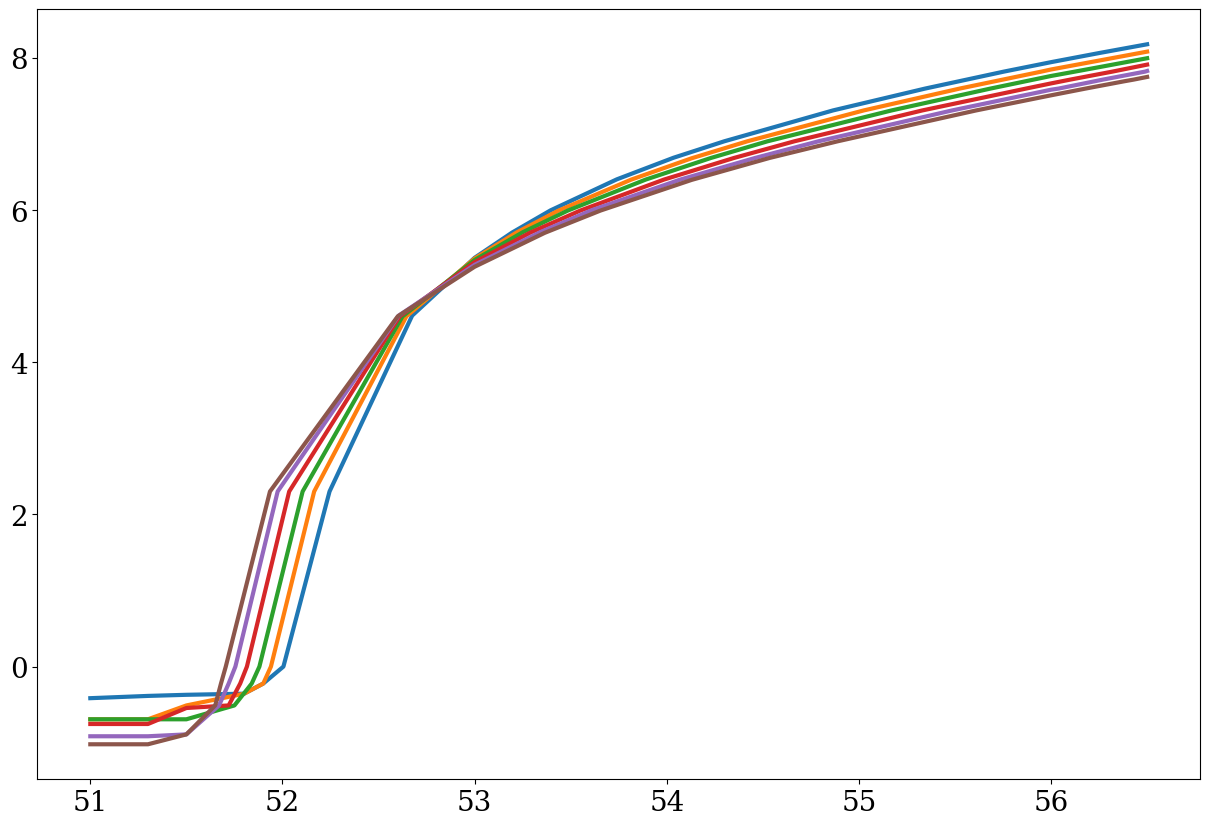

In [21]:
plt.figure(figsize=(15, 10))
# plt.plot(V25, np.log(I25*1e3), lw=3, label=f'T = {25}ºC')
plt.plot(V25v0, np.log(I25v0*1e3), lw=3, label=f'T = {25}ºC first round')
# plt.plot(V25, np.log(I25v1*1e3), '-*', lw=3, label=f'T = {25}ºC second round')
# plt.plot(V25, np.log(I25v2*1e3), '--*', lw=3, label=f'T = {25}ºC different SiPM')
plt.plot(V22, np.log(I22*1e3), lw=3, label=f'T = {22}ºC')
plt.plot(V19, np.log(I19*1e3), lw=3, label=f'T = {19}ºC')
plt.plot(V16, np.log(I16*1e3), lw=3, label=f'T = {16}ºC')
plt.plot(V13, np.log(I13*1e3), lw=3, label=f'T = {13}ºC')
plt.plot(V10, np.log(I10*1e3), lw=3, label=f'T = {10}ºC')

plt.plot(53*np.ones_like(I25v2), np.linspace(np.log(I25v2*1e3).min(), np.log(I25v2*1e3).max(), len(I25)), ls=':', lw=3, label=r'Reference $V_{BR}$')

# plt.xlim(50., 55)
# plt.ylim(0, .4)

plt.ylabel(r"log(I) [$n$A]")
plt.xlabel(r"V [V]")
plt.legend()
plt.grid()
# plt.yscale('log')

NameError: name 'V25' is not defined

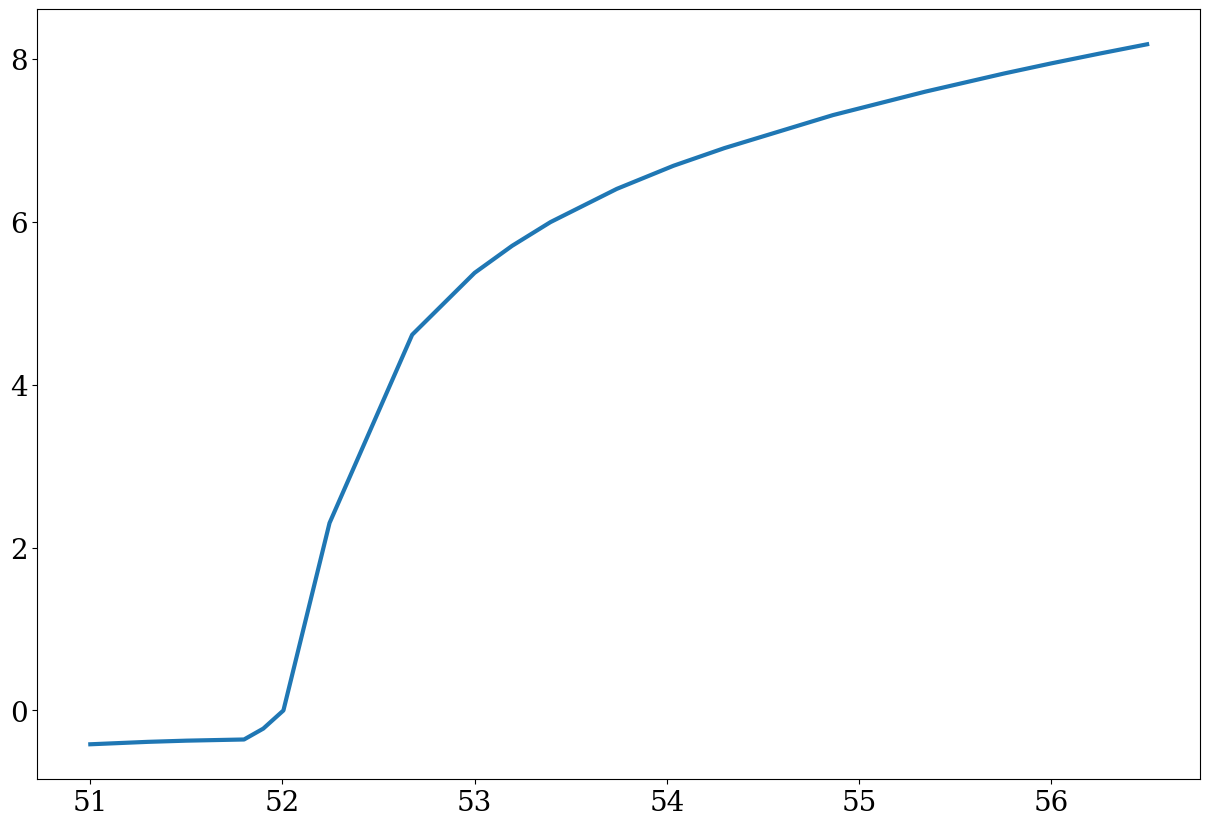

In [22]:
plt.figure(figsize=(15, 10))
# plt.plot(V25, np.log(I25*1e3), lw=3, label=f'T = {25}ºC')
plt.plot(V25v0, np.log(I25v0*1e3), lw=3, label=f'T = {25}ºC first round')
plt.plot(V25, np.log(I25v1*1e3), '-*', lw=3, label=f'T = {25}ºC second round')
plt.plot(V25, np.log(I25v2*1e3), '--*', lw=3, label=f'T = {25}ºC different SiPM')
# plt.plot(V22, I22, lw=3, label=f'T = {22}ºC')
# plt.plot(V19, I19, lw=3, label=f'T = {19}ºC')
# plt.plot(V16, I16, lw=3, label=f'T = {16}ºC')
# plt.plot(V13, I13, lw=3, label=f'T = {13}ºC')
# plt.plot(V10, I10, lw=3, label=f'T = {10}ºC')

plt.plot(53*np.ones_like(I25v2), np.linspace(np.log(I25v2*1e3).min(), np.log(I25v2*1e3).max(), len(I25)), ls=':', lw=3, label=r'Reference $V_{BR}$')

plt.xlim(50., 55)
# plt.ylim(0, .4)

plt.ylabel(r"log(I) [$n$A]")
plt.xlabel(r"V [V]")
plt.legend()
plt.grid()
# plt.yscale('log')

In [23]:
a = pd.read_hdf('/data/marian/IC/LT/20250702_NEXT100fibers_S1_LT.h5', '/LT/LightTable')

FileNotFoundError: File /data/marian/IC/LT/20250702_NEXT100fibers_S1_LT.h5 does not exist

In [24]:
!echo $ICDIR

In [25]:
b = pd.read_hdf('/scratch/marian/IC/invisible_cities/database/test_data/NEXT100_S1_LT.h5', '/LT/LightTable')

FileNotFoundError: File /scratch/marian/IC/invisible_cities/database/test_data/NEXT100_S1_LT.h5 does not exist

In [26]:
b['PmtR11410_2'].sum()

NameError: name 'b' is not defined

In [27]:
a.loc[a['SiPMf_202'] > 0]

NameError: name 'a' is not defined

In [28]:
c = pd.read_hdf('/data/marian/IC/LT/20250709_NEXT100fibers_S1_LT.h5', '/LT/LightTable')


FileNotFoundError: File /data/marian/IC/LT/20250709_NEXT100fibers_S1_LT.h5 does not exist

In [29]:
16*16*60

15360

In [30]:
16*16*60

15360

In [31]:
len(b), 

NameError: name 'b' is not defined

In [32]:
len(b.z.unique()), len(c.z.unique())

NameError: name 'b' is not defined

In [33]:
b.x.min(), b.x.max(), b.y.min(), b.y.max(), b.z.min(), b.z.max()

NameError: name 'b' is not defined

In [34]:
c.x.min(), c.x.max(), c.y.min(), c.y.max(), c.z.min(), c.z.max()

NameError: name 'c' is not defined

In [35]:
len(b), np.shape(c)

NameError: name 'b' is not defined

In [36]:
c

NameError: name 'c' is not defined

In [37]:
c.loc[c['SiPMf_202'] > 0]

NameError: name 'c' is not defined

In [38]:
c.SiPMf_223.sum(), c.SiPMf_275.sum(), c.SiPMf_203.sum(), c.SiPMf_total.max()

NameError: name 'c' is not defined

In [39]:
b.PmtR11410_0.sum(), b.PmtR11410_1.sum(), b.PmtR11410_total.max()


NameError: name 'b' is not defined

In [40]:
c

NameError: name 'c' is not defined

In [41]:
b.min()

NameError: name 'b' is not defined

In [42]:
b.loc[b['PmtR11410_0'] > 0]

NameError: name 'b' is not defined

In [43]:

import sys
sys.path.append('/home/investigator/mariandbt/python/notebooks/modules')
sys.path.append('/scratch/marian/s2simulation/modules')
from import_modules import *
import set_up as setup


ModuleNotFoundError: No module named 'import_modules'

In [44]:

path = '/data/marian/'
path = path + '/s2simulation/s1'


list_of_ev_file_paths = []
for i in range(30):
    file_path = os.path.join(path, f'20250522_NEXT100fibers_100ev_100Kph_S1_param_{i+1}.next.h5')
    list_of_ev_file_paths.append(file_path)

NameError: name 'os' is not defined

In [45]:
list_of_ev_file_paths

[]

In [46]:
setup.check_h5(list_of_ev_file_paths[0])

NameError: name 'setup' is not defined

In [47]:
aa = pd.read_hdf(list_of_ev_file_paths[0], '/MC/particles')
bb = pd.read_hdf(list_of_ev_file_paths[0], '/MC/sns_response')


IndexError: list index out of range

In [48]:
cc = pd.read_hdf(list_of_ev_file_paths[1], '/MC/particles')
dd = pd.read_hdf(list_of_ev_file_paths[1], '/MC/sns_response')

IndexError: list index out of range

In [49]:
_, ee = setup.read_fiber_sens(list_of_ev_file_paths[0])


NameError: name 'setup' is not defined

In [50]:
ee.charge.sum()

NameError: name 'ee' is not defined

In [51]:
ee.max()

NameError: name 'ee' is not defined

In [52]:
ee.groupby('event_id').max()

NameError: name 'ee' is not defined

In [53]:
ee.groupby('sensor_id').sum().charge.min()

NameError: name 'ee' is not defined

In [54]:
aa

NameError: name 'aa' is not defined

In [55]:
cc

NameError: name 'cc' is not defined

In [56]:
bb.groupby('event_id').sum()

NameError: name 'bb' is not defined

In [57]:
dd.loc[dd.event_id == 0].charge.sum()

NameError: name 'dd' is not defined